# Analyse des données

Bienvenue dans la partie Analyse de donnée.

Dans cette partie, je vais partir de la jointure et des bases de données nettoyées précedemment.

## Chargement des bibliothèques

Pour cela, je vais d'abord charger les bibliothèques dont j'aurai besoin :

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données

Je charge maintenant la table Contrat et la jointure entre la table Sinistre et la table Contrat pour l'analyse, avec un aperçu pour chacune d'elles :

In [6]:
df = pd.read_csv('base_sinistralite_pure.csv', sep=';', encoding='utf-8-sig')

print(df.head(5))

  identifiant_contrat  annee_exercice immatriculation_vehicule  date_debut  \
0          C002919456            2019               JT-1368-MM  2019-01-01   
1          C002919866            2019               ZL-4429-JR  2019-01-01   
2          C002919935            2019               BM-9154-RS  2019-01-01   
3          C002919964            2019               PM-8659-KX  2019-01-01   
4          C003297596            2019               HD-9121-JN  2019-01-01   

     date_fin  exposition  age_conducteur genre_conducteur   type_permis  \
0  2019-12-31         1.0           41.15            Homme  Traditionnel   
1  2019-12-31         1.0           62.23            Femme  Traditionnel   
2  2019-12-31         1.0           41.70            Homme  Traditionnel   
3  2019-12-31         1.0           31.79            Femme  Traditionnel   
4  2019-12-31         1.0           46.81            Femme  Traditionnel   

   anciennete_permis  ...  cotisation_vhr source_garantie  \
0            

In [6]:
df_contrat = pd.read_csv('contrat_cleaned.csv', sep=';', encoding='utf-8-sig')

print(df.head(5))

  identifiant_contrat  annee_exercice immatriculation_vehicule  date_debut  \
0          C002919456            2019               JT-1368-MM  2019-01-01   
1          C002919866            2019               ZL-4429-JR  2019-01-01   
2          C002919935            2019               BM-9154-RS  2019-01-01   
3          C002919964            2019               PM-8659-KX  2019-01-01   
4          C003297596            2019               HD-9121-JN  2019-01-01   

     date_fin  exposition  age_conducteur genre_conducteur   type_permis  \
0  2019-12-31         1.0           41.15            Homme  Traditionnel   
1  2019-12-31         1.0           62.23            Femme  Traditionnel   
2  2019-12-31         1.0           41.70            Homme  Traditionnel   
3  2019-12-31         1.0           31.79            Femme  Traditionnel   
4  2019-12-31         1.0           46.81            Femme  Traditionnel   

   anciennete_permis  ...  cotisation_vhr source_garantie  \
0            

## Analyse des données

### 1. Histogramme du total de sinistres par année

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\86243151.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='annee', palette='Blues_d')


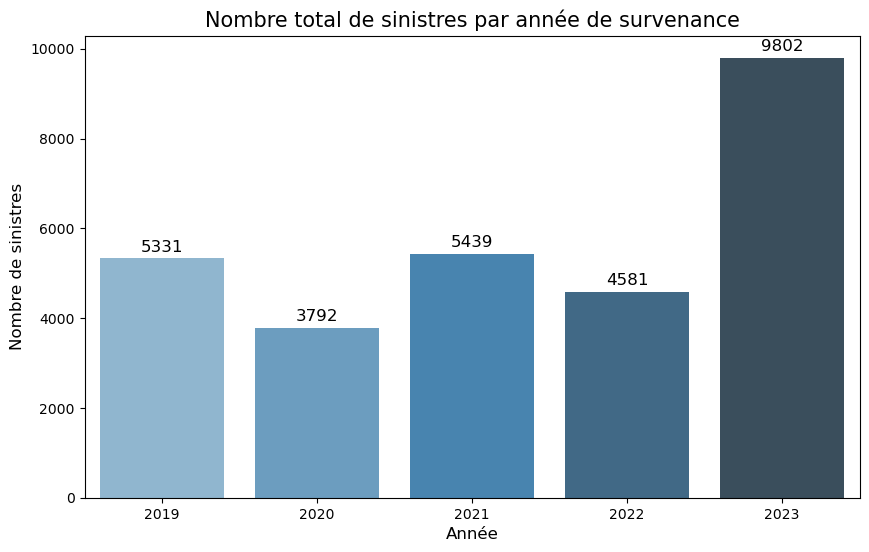

In [7]:
df['date_survenance_sinistre'] = pd.to_datetime(df['date_survenance_sinistre'])

# Extraction de l'année
df['annee'] = df['date_survenance_sinistre'].dt.year

# Création du graphique
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='annee', palette='Blues_d')

# Ajout des valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Nombre total de sinistres par année de survenance', fontsize=15)
plt.xlabel('Année', fontsize=12)
plt.ylabel('Nombre de sinistres', fontsize=12)
plt.show()

On constate un taux plus bas en 2020, on peut faire le lien avec la crise du Covid-19.

### 2. Distribution des contrats par année d’exercice

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\752546588.py:1: DtypeWarning: Columns (33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_contrat = pd.read_csv('contrat_cleaned.csv', sep=';', encoding='utf-8-sig')
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\752546588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=contrats_par_an, x='annee_exercice', y='identifiant_contrat', palette='viridis')


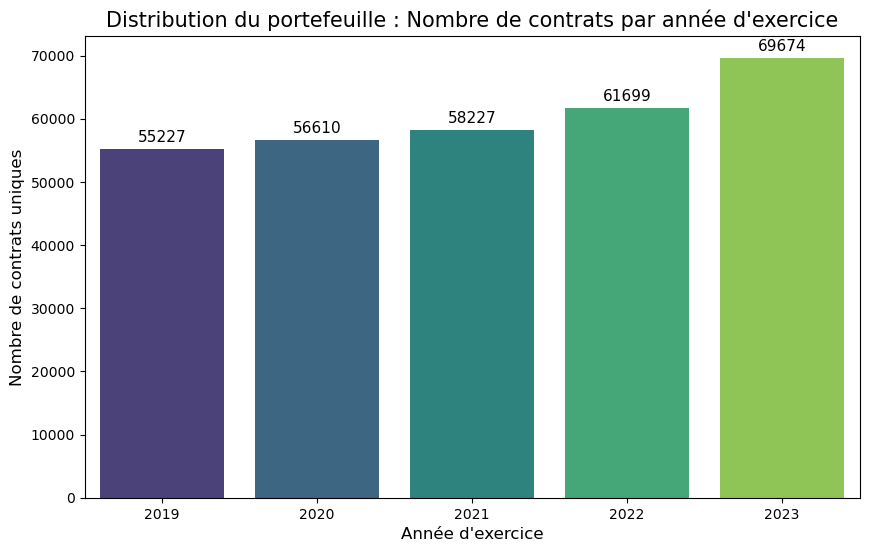

In [8]:
contrats_par_an = df_contrat.groupby('annee_exercice')['identifiant_contrat'].nunique().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=contrats_par_an, x='annee_exercice', y='identifiant_contrat', palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.title('Distribution du portefeuille : Nombre de contrats par année d\'exercice', fontsize=15)
plt.xlabel('Année d\'exercice', fontsize=12)
plt.ylabel('Nombre de contrats uniques', fontsize=12)
plt.show()

Le nombre de contrats augmente d'année en année depuis 2019. En revanche, le nombre de sinistre ne suit pas cette tendance. On peut donc en déduire une fluctuation de la fréquence de sinistre au fil des années.

### 3. Bar plot de répartition des types de véhicules

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\657293913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_contrat, y='segment_vehicule',


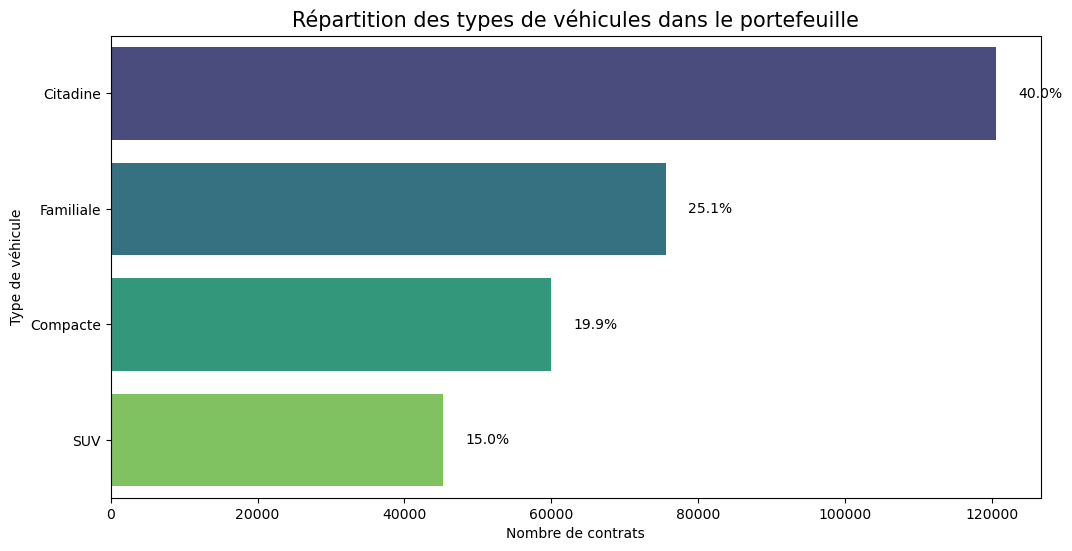

In [10]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(data=df_contrat, y='segment_vehicule', 
                   order=df_contrat['segment_vehicule'].value_counts().index, 
                   palette='viridis')

total = len(df_contrat)
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    x = p.get_width() + (0.01 * total) # Positionnement du texte
    y = p.get_y() + p.get_height() / 2
    ax.annotate(percentage, (x, y), va='center')

plt.title('Répartition des types de véhicules dans le portefeuille', fontsize=15)
plt.xlabel('Nombre de contrats')
plt.ylabel('Type de véhicule')
plt.show()

### 4. Répartition des véhicules selon l’alimentation

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\1956576443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_contrat, x='alimentation_vehicule',


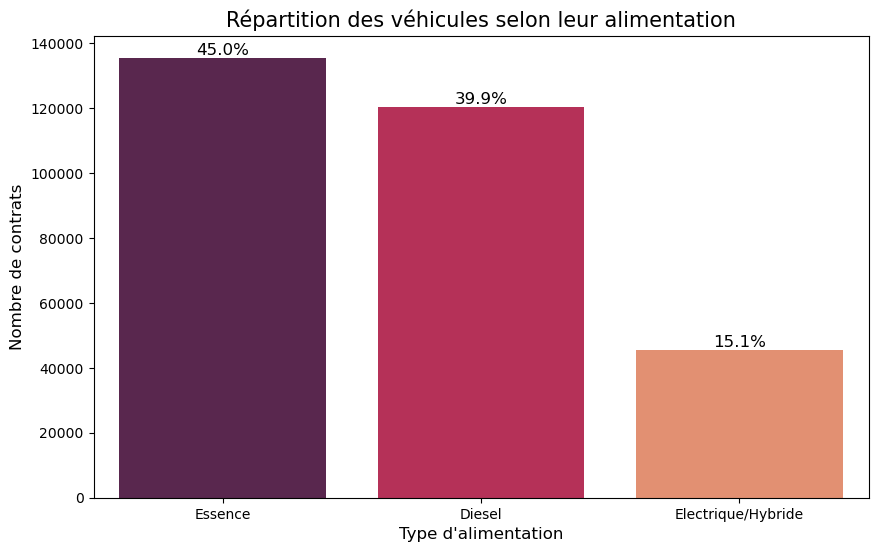

In [11]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df_contrat, x='alimentation_vehicule', 
                   order=df_contrat['alimentation_vehicule'].value_counts().index, 
                   palette='rocket')

total = len(df_contrat)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=12)

plt.title('Répartition des véhicules selon leur alimentation', fontsize=15)
plt.xlabel('Type d\'alimentation', fontsize=12)
plt.ylabel('Nombre de contrats', fontsize=12)
plt.show()

On remarque une nette domination des véhicules essence et diesel pour les sinistres. Cela peut aussi être dû à leur nombre plus important. De plus, les véhicules Diesel sont utilisés par des "gros rouleurs" (plus de kilomètres), ce qui augmente mécaniquement la probabilité d'un sinistre.

### 5. Histogramme des contrats avec ou sans option petit rouleur

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\455283286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_contrat, x='petit_rouleur', palette='coolwarm')


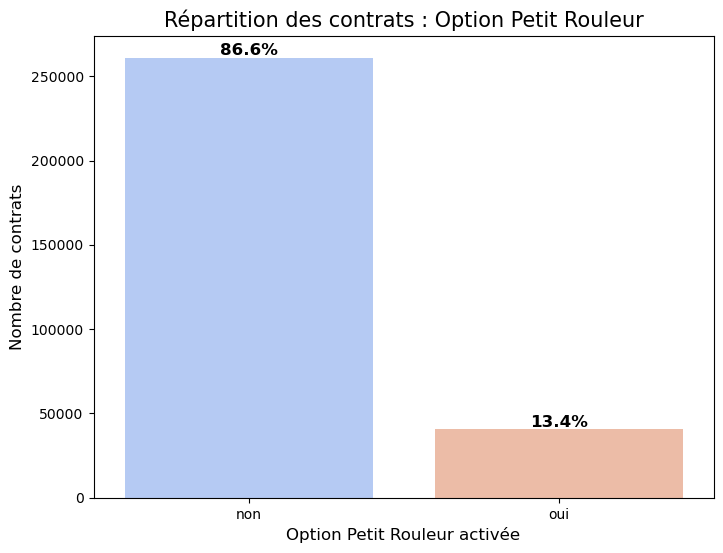

In [13]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df_contrat, x='petit_rouleur', palette='coolwarm')

total = len(df_contrat)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Répartition des contrats : Option Petit Rouleur', fontsize=15)
plt.xlabel('Option Petit Rouleur activée', fontsize=12)
plt.ylabel('Nombre de contrats', fontsize=12)
plt.show()

le "NON" domine largement (> 80%), il s'agit d'un portefeuille de "rouleurs standards" ou de pendulaires (trajets travail-domicile).

### 6. Nombre de sinistres en fonction de l’âge du sociétaire

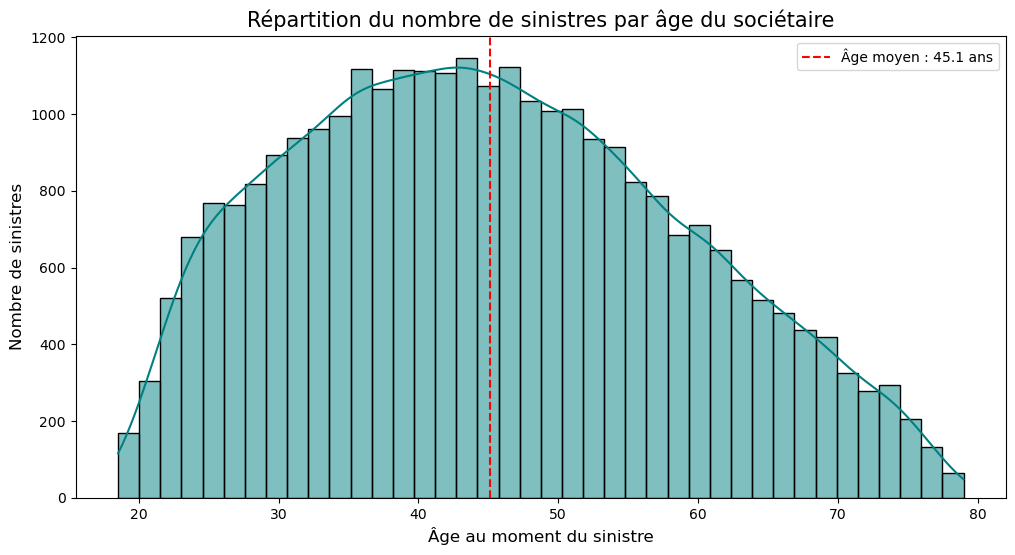

In [16]:
plt.figure(figsize=(12, 6))

sns.histplot(df, x='age_conducteur', bins=40, kde=True, color='teal')

age_moyen = df['age_conducteur'].mean()
plt.axvline(age_moyen, color='red', linestyle='--', label=f'Âge moyen : {age_moyen:.1f} ans')

plt.title('Répartition du nombre de sinistres par âge du sociétaire', fontsize=15)
plt.xlabel('Âge au moment du sinistre', fontsize=12)
plt.ylabel('Nombre de sinistres', fontsize=12)
plt.legend()
plt.show()

Il y a énormément de sinistres vers 40 ans, c'est peut-être juste parce que la majorité des clients a 40 ans. 

### 7. Nombre de sinistres selon le nombre de sinistres antécédents

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\3298366194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(df, x='sinistres_anterieurs', palette='autumn')


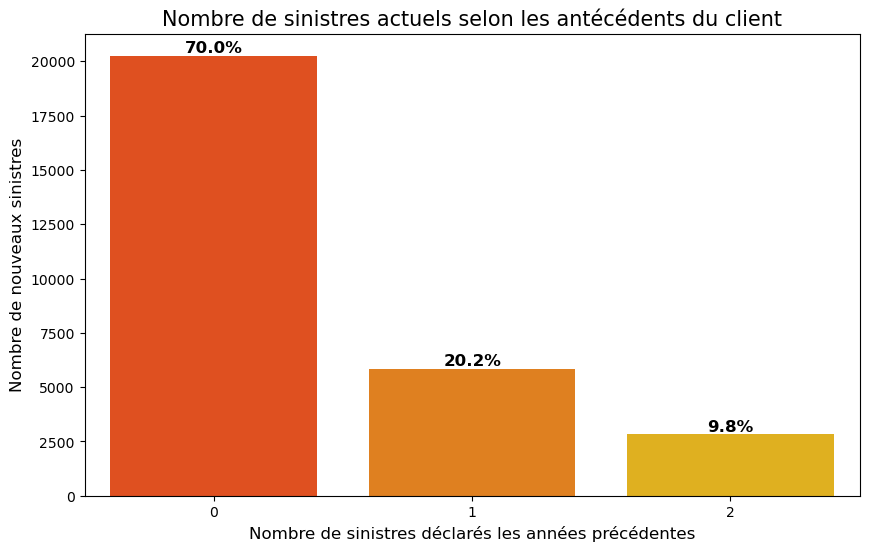

In [17]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(df, x='sinistres_anterieurs', palette='autumn')

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Nombre de sinistres actuels selon les antécédents du client', fontsize=15)
plt.xlabel('Nombre de sinistres déclarés les années précédentes', fontsize=12)
plt.ylabel('Nombre de nouveaux sinistres', fontsize=12)
plt.show()

Il est normal que la barre "0 antécédent" soit la plus haute. La plupart des gens n'ont pas d'accident chaque année. Plus le nombre d'antécédents augmente, plus le nombre de sinistres diminue car peu de clients ont plus de 4 ou 5 sinistres.

### 8. Nombre de sinistres par segment commercial du véhicule

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12864\915826383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


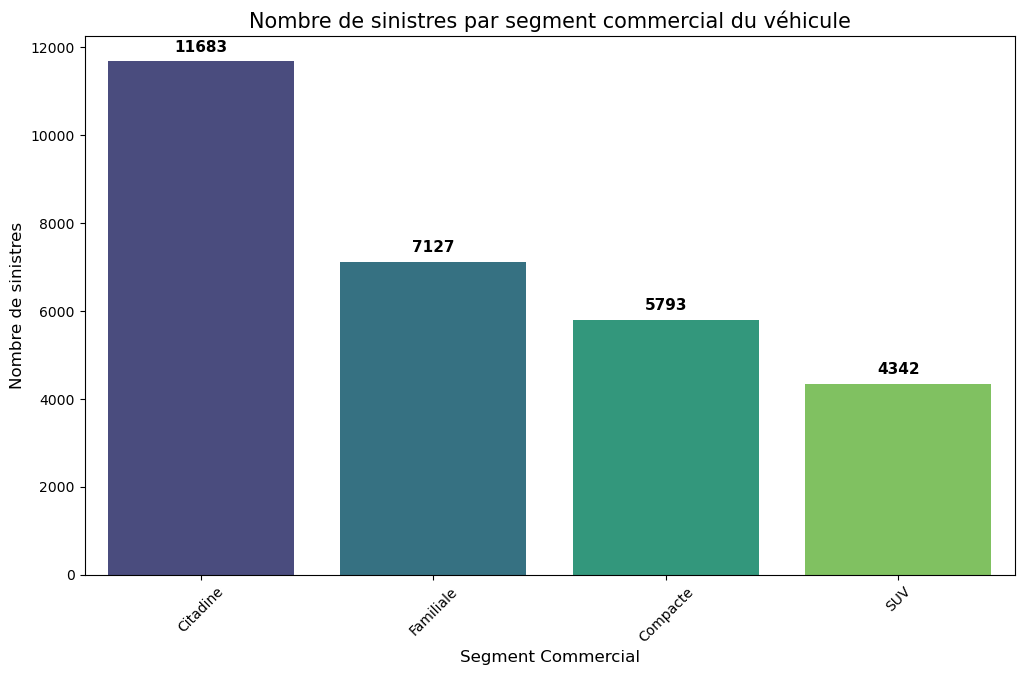

In [18]:
plt.figure(figsize=(12, 7))

segment_counts = df['segment_vehicule'].value_counts()

ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Nombre de sinistres par segment commercial du véhicule', fontsize=15)
plt.xlabel('Segment Commercial', fontsize=12)
plt.ylabel('Nombre de sinistres', fontsize=12)
plt.xticks(rotation=45) # Rotation si les noms de segments sont longs
plt.show()

Le segment "Citadine" est en tête, c'est probablement parce qu'il représente la majorité des contrats.

### 9. Nombre et pourcentage de sinistres selon le sexe

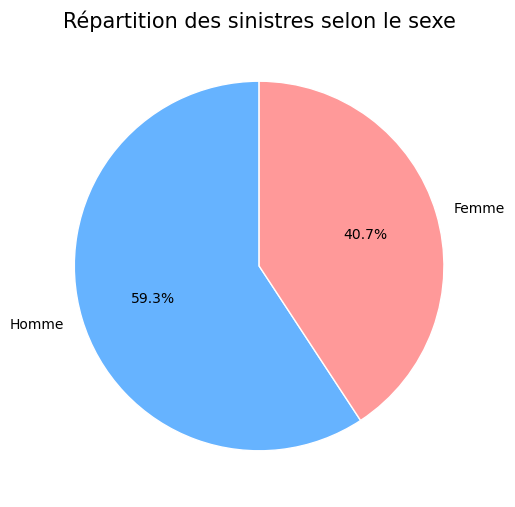

Détail des sinistres par sexe :
genre_conducteur
Homme    17150
Femme    11795
Name: count, dtype: int64


In [19]:
sexe_counts = df['genre_conducteur'].value_counts()
sexe_pct = df['genre_conducteur'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))

plt.pie(sexe_counts, labels=sexe_counts.index, autopct='%1.1f%%', 
        colors=['#66b3ff', '#ff9999'], startangle=90, wedgeprops={'edgecolor': 'white'})

plt.title('Répartition des sinistres selon le sexe', fontsize=15)
plt.show()

print("Détail des sinistres par sexe :")
print(sexe_counts)